In [1]:
import torch
import torchvision.models as models
import backbone.Test as test
import timm
import backbone.Custom as Custom
from torch.utils.data import Dataset, DataLoader
import backbone.VISUAL as viz
import backbone.GalaxyZoo as gz
import importlib
import backbone.AstroMLmodified as AstroMLmod

/users/koketso/.venv/deepclustering3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-20 17:49:07.762234: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768924148.745178 1172607 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768924149.007835 1172607 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-20 17:49:10.585912: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-



Failed to import TF-Keras. Please note that TF-Keras is not installed by default when you install TensorFlow Probability. This is so that JAX-only users do not have to install TensorFlow or TF-Keras. To use TensorFlow Probability with TensorFlow, please install the tf-keras or tf-keras-nightly package.
This can be be done through installing the tensorflow-probability[tf] extra.




<Figure size 640x480 with 0 Axes>

# Data

In [31]:
train,val,class_  = gz.Galaxy_zoo_data_loaders(val_split = None)

In [ ]:
## Model: Zoobot ConvNext Base

zoobot_encoder = timm.create_model('hf_hub:mwalmsley/zoobot-encoder-convnext_base', pretrained=True, num_classes=0)


importlib.reload(Custom)
zoobot_rep, zoobot_label, zoobot_ids = Custom.get_representations(model  = zoobot_encoder,
                           loader = train,
                           encoder = True,
                           labeled = False)


zoobot_rep_c, zoobot_label_c, zoobot_ids_c = Custom.get_representations(model  = zoobot_encoder,
                           loader = class_,
                           encoder = True,
                           labeled = True)

#umap_cs  =viz.umap(zoobot_rep_c)

pca_var,pca_dim = viz.pca(zoobot_rep,
                          
                          return_variance_dimension = True)
knn = test.KNN_accuracy(zoobot_rep_c,
                        zoobot_label_c)
print("KNN: ",knn)
zc_accuracy = test.clustering_accuracy((zoobot_rep,zoobot_ids),(zoobot_label_c,zoobot_ids_c))
zoobot_tpcf = AstroMLmod.TPCF_score(zoobot_rep)
print("TPCF: ",zoobot_tpcf)
zoobot_id = AstroMLmod.id_score(zoobot_rep)
print("ID: ",zoobot_id)

In [35]:
zoobot_tpcf = AstroMLmod.TPCF_score(zoobot_rep)


## Model: Dino ConvNext base

In [ ]:
dinov3_convnext_base = torch.hub.load("../dinov3", 'dinov3_convnext_base',
                                      source='local',
                                      weights="dinov3_convnext_base_pretrain_lvd1689m-801f2ba9.pth")
dino_rep, dino_label, dino_ids = Custom.get_representations(model  = dinov3_convnext_base,
                           loader = train,
                           encoder = True,
                           labeled = False)

dino_rep_c, dino_label_c, dino_ids_c = Custom.get_representations(model  = dinov3_convnext_base,
                           loader = class_,
                           encoder = True,
                           labeled = True)

#umap_  =viz.umap(dino_rep)

dino_pca_var,dino_pca_dim = pca(dino_rep,return_variance_dimention = True)
dino_knn = test.KNN_accuracy(dino_rep_c, dino_label_c)
print(dino_knn)
dc_accuracy = test.clustering_accuracy((dino_rep,dino_ids),(dino_label_c,dino_ids_c))
dino_tpcf = AstroMLmod.TPCF_score(dino_rep)
print(dino_tpcf)
dono_id = AstroMLmod.id_score(dino_rep)
print(dono_id)

## Model: ImageNet representations ConvNext base

In [ ]:
import torchvision as tv
weights = tv.models.ConvNeXt_Base_Weights.IMAGENET1K_V1

imnet_convnext_base = tv.models.convnext_base(weights = weights)

imnet_rep, imnet_label, imnet_ids = Custom.get_representations(model  = imnet_convnext_base,
                           loader = train,
                           encoder = True,
                           labeled = False)

imnet_rep_c, imnet_label_c, imnet_ids_c = Custom.get_representations(model  = imnet_convnext_base,
                           loader = class_,
                           encoder = True,
                           labeled = True)

#umap_  =viz.umap(imnet_rep)

imnet_pca_var,imnet_pca_dim = viz.pca(imnet_rep,return_variance_dimension = True)
imnet_knn = test.KNN_accuracy(imnet_rep_c, imnet_label_c)
print(imnet_knn)
ic_accuracy = test.clustering_accuracy((imnet_rep,imnet_ids),(imnet_label_c,imnet_ids_c))
imnet_tpcf = AstroMLmod.TPCF_score(imnet_rep)
print(imnet_tpcf)
imnet_id = AstroMLmod.id_score(imnet_rep)
print(imnet_id)

## Model: ImageNet representations ConvNext base

In [ ]:
import torchvision as tv
weights = tv.models.ResNet18_Weights.IMAGENET1K_V1 


imnet_resnet18 = tv.models.resnet18(weights = weights)

imnet_resnet18.fc = torch.nn.Identity()

res_imnet_rep, res_imnet_label, res_imnet_ids = Custom.get_representations(model  = imnet_resnet18,
                           loader = train,
                           encoder = True,
                           labeled = False)

res_imnet_rep_c, res_imnet_label_c, res_imnet_ids_c = Custom.get_representations(model  = imnet_resnet18,
                           loader = class_,
                           encoder = True,
                           labeled = True)

#umap_  =viz.umap(imnet_rep)

importlib.reload(AstroMLmod)
importlib.reload(test)
res_imnet_pca_var,res_imnet_pca_dim = viz.pca(res_imnet_rep,return_variance_dimension = True)
res_imnet_knn = test.KNN_accuracy(res_imnet_rep_c, res_imnet_label_c)
print("KNN: ",res_imnet_knn)
res_ic_accuracy = test.clustering_accuracy((res_imnet_rep,res_imnet_ids),(res_imnet_label_c,res_imnet_ids_c))
res_imnet_tpcf = AstroMLmod.TPCF_score(res_imnet_rep)
print("TPCF score: ",res_imnet_tpcf)
res_imnet_id = AstroMLmod.id_score(res_imnet_rep)
print("ID :",res_imnet_id)

## Clustering accuracy

findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not

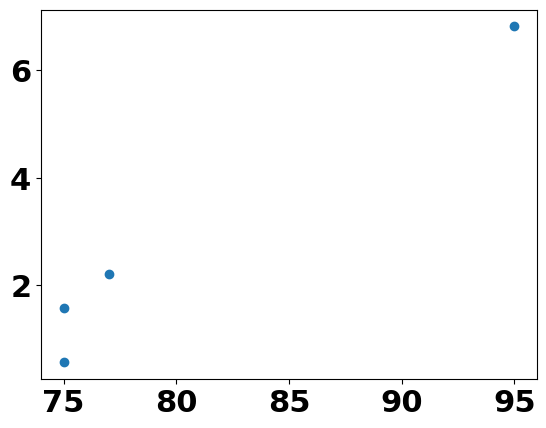

In [23]:
import matplotlib.pyplot as plt
"conv_zoobot,conv_dino,conv_imnet,res_imnet"
x = [75,75,77,95]
y = [0.56,1.58,2.21,6.82]
plt.scatter(x,y)